In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import fbu
physical_devices = tf.config.list_physical_devices('GPU') 
for device in physical_devices:
    tf.config.experimental.set_memory_growth(device, True)
from methods import IBU, NPU, MADE

import tensorflow_probability as tfp
from matplotlib import gridspec

tfd = tfp.distributions
tfpl = tfp.layers
tfk = tf.keras
tfkl = tf.keras.layers
tfb = tfp.bijectors

In [2]:
np.version.version

'1.20.0'

In [3]:
# Visualization from Jay: https://github.com/qwerasd903/UnbinnedProfiledUnfolding/blob/main/UnbinnedProfiledUnfolding.ipynb

class comparison_plots_with_ratio:
    
    def __init__(self, xmin, xmax, nbins, xlabel=r"$T$", ratio_label="Data/Pred.", header="Gaussian Example", density=True, save_name=None, legend_corner="upper left"):
        
        self.xmin = xmin
        self.xmax = xmax
        self.nbins = nbins
        self.density = density
        self.save_name = save_name
        self.legend_corner = legend_corner
        self.nTt = None
        self.bTt = None
        self.nTs = []
        self.bTs = []
        self.argss = []
        
        fig = plt.figure(figsize=(8, 8))
        gs = gridspec.GridSpec(2, 1, height_ratios=[3,1])
        
        self.ax0 = plt.subplot(gs[0])
        self.ax0.yaxis.set_ticks_position('both')
        self.ax0.xaxis.set_ticks_position('both')
        self.ax0.tick_params(direction="in", which="both")
        plt.xticks(fontsize=0)
        plt.yticks(fontsize=20)
        self.ax0.minorticks_on()
        
        plt.ylabel("Normalized to Unity" if self.density else "Events", fontsize=20)
        plt.xlim([xmin,xmax])
        plt.title(header,loc="right",fontsize=20, fontstyle="italic")
        
        self.ax1 = plt.subplot(gs[1])
        self.ax1.yaxis.set_ticks_position('both')
        self.ax1.xaxis.set_ticks_position('both')
        self.ax1.tick_params(direction="in",which="both")
        self.ax1.minorticks_on()
        
        plt.xlim([xmin,xmax])
        plt.locator_params(axis='x', nbins=6)
        plt.xlabel(xlabel,fontsize=20)
        plt.ylabel(ratio_label,fontsize=20)
        plt.xticks(fontsize=20)
        plt.yticks(fontsize=15)
        plt.axhline(y=1,linewidth=2, color='gray')   
        plt.ylim(0.5,1.5)
        
    def add_data(self, data, label, target=False, weights=None, histtype=None, color=None, ls=None, lw=None, alpha=None):
        args = {"label": label}
        if type(weights) != type(None): args["weights"] = weights
        if type(histtype) != type(None): args["histtype"] = histtype
        if type(color) != type(None): args["color"] = color
        if type(ls) != type(None): args["ls"] = ls
        if type(lw) != type(None): args["lw"] = lw
        if type(alpha) != type(None): args["alpha"] = alpha
        nT, bT, _ = self.ax0.hist(data, bins=np.linspace(self.xmin, self.xmax, self.nbins), density=self.density, **args)
        if target:
            self.nTt = nT
            self.bTt = bT
        else:
            self.nTs.append(nT)
            self.bTs.append(bT)
            self.argss.append(args)
        
    def plot_ratio(self):
        if type(self.nTt) == type(None):
            return
        for nT, bT, _args in zip(self.nTs, self.bTs, self.argss):
            args = {}
            if "color" in _args: args["color"] = _args["color"]
            if "ls" in _args: args["ls"] = _args["ls"]
            self.ax1.plot(0.5*(self.bTt[1:]+self.bTt[:-1]),self.nTt/(0.000001+nT), **args)
            
    def save(self):
        if type(self.save_name) == type(None):
            return
        os.makedirs("plot", exist_ok=True)
        if os.path.isfile(f"plot/{self.save_name}.pdf"):
            i = 0
            while os.path.isfile(f"plot/{self.save_name}_{i}.pdf"):
                i += 1
            self.save_name = f"{self.save_name}_{i}"
        plt.savefig(f"plot/{self.save_name}.pdf", bbox_inches='tight')
    
    def show(self):
        self.plot_ratio()
        self.ax0.locator_params(axis='y', nbins=6)
        self.ax0.legend(frameon=False,fontsize=20, loc=self.legend_corner)
        self.save()
        plt.show()
        plt.clf()

In [4]:
import energyflow as ef

In [5]:
samples = {'Pythia26': ef.zjets_delphes.load('Pythia26', num_data=1000000,cache_dir="/global/cfs/projectdirs/m3246/bnachman/OmniFold"),
            'Pythia25': ef.zjets_delphes.load('Pythia25', num_data=1000000,cache_dir="/global/cfs/projectdirs/m3246/bnachman/OmniFold"),
            'Pythia21': ef.zjets_delphes.load('Pythia21', num_data=1000000,cache_dir="/global/cfs/projectdirs/m3246/bnachman/OmniFold"),
            'Herwig': ef.zjets_delphes.load('Herwig', num_data=1000000,cache_dir="/global/cfs/projectdirs/m3246/bnachman/OmniFold")}

<__array_function__ internals>:5: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.


In [6]:
samples['Pythia26'].keys()

dict_keys(['gen_ang2s', 'gen_particles', 'gen_Zs', 'gen_jets', 'gen_sdms', 'gen_mults', 'gen_widths', 'gen_zgs', 'gen_tau2s', 'gen_lhas', 'sim_ang2s', 'sim_particles', 'sim_jets', 'sim_sdms', 'sim_mults', 'sim_widths', 'sim_zgs', 'sim_tau2s', 'sim_lhas'])

In [7]:
# nEvents = min(len(madgraph_0["T_Ptyy"]),len(data["T_Ptyy"]))
nEvents = 1000000
# print(f"Restrict to {nEvents} events.")

In [8]:
T_sim = samples['Pythia21']['gen_widths']
R_sim = samples['Pythia21']['sim_widths']
T_data = samples['Herwig']['gen_widths']
R_data = samples['Herwig']['sim_widths']

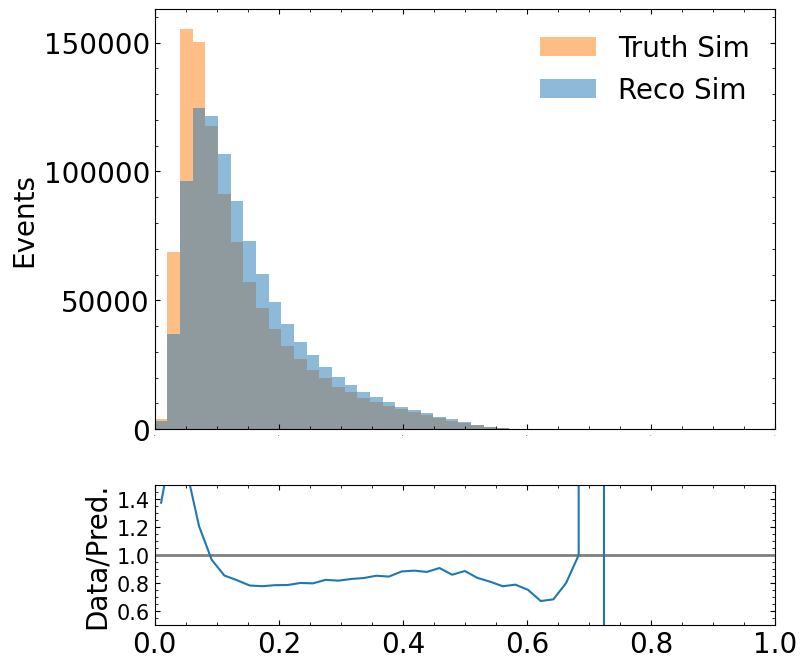

<Figure size 640x480 with 0 Axes>

In [9]:
cpwr = comparison_plots_with_ratio(0, 1, 50, xlabel=r"", density=False, legend_corner="upper right", header=r"")
cpwr.add_data(T_sim, label="Truth Sim", target=True, alpha=0.5, color='tab:orange')
cpwr.add_data(R_sim, label="Reco Sim", alpha=0.5, color='tab:blue')
#cpwr.add_data(T_data, label="Truth Data", target=True, alpha=0.5, color='tab:pink')
#cpwr.add_data(R_data, label="Reco Data", alpha=0.5, color='tab:green')
cpwr.show()

In [10]:
#For the binning, make it so we have 50% in each bin growing from the low side
binvals = [0]
i = 0
while binvals[-1] < 1:
    for binhigh in np.linspace(binvals[-1]+0.01,1.1,20):
        purity = len(T_sim[(T_sim > binvals[i])*(T_sim < binhigh)*(R_sim > binvals[i])*(R_sim < binhigh)]) / len(T_sim[(T_sim > binvals[i])*(T_sim < binhigh)])
        if (purity > 0.5**0.5):
            print(binhigh,purity)
            i+=1
            binvals+=[binhigh]
            break
        elif (binhigh > 1):
            print(binhigh,purity)
            binvals+=[binhigh]
            break
print(binvals)

0.12473684210526316 0.8095569387888532
0.23634349030470914 0.8072898281285545
0.3362020702726345 0.754457400894254
0.4255492207702519 0.7193767355754397
0.5404625017012648 0.7210440456769984
1.0132309213212525 0.4609595484477893
[0, 0.12473684210526316, 0.23634349030470914, 0.3362020702726345, 0.4255492207702519, 0.5404625017012648, 1.0132309213212525]


In [11]:
#Next, let's construct the response matrix.

wbin_truth = np.clip(np.digitize(T_sim,binvals),1,len(binvals)-1)-1
wbin_reco = np.clip(np.digitize(R_sim,binvals),1,len(binvals)-1)-1
H_pT, xedges, yedges = np.histogram2d(wbin_truth,wbin_reco,bins=[range(len(binvals)),range(len(binvals))])

#data
wbin_truth_data = np.clip(np.digitize(T_data,binvals),1,len(binvals)-1)-1
wbin_reco_data = np.clip(np.digitize(R_data,binvals),1,len(binvals)-1)-1
H_pT_data, _, _ = np.histogram2d(wbin_truth_data,wbin_reco_data,bins=[range(len(binvals)),range(len(binvals))])

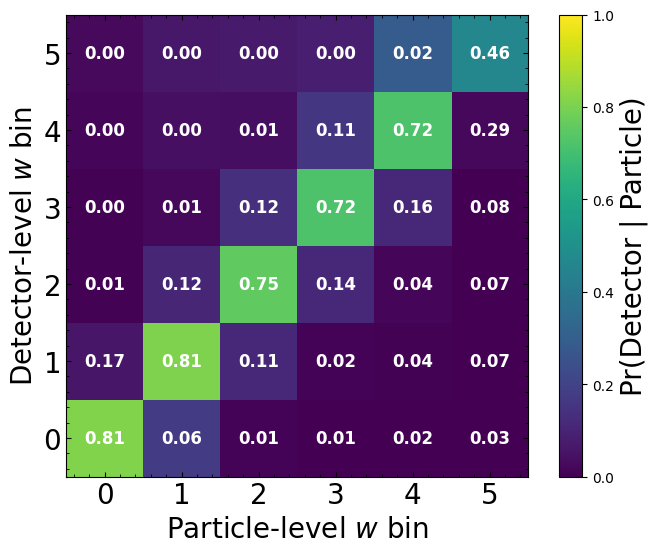

In [29]:
fig = plt.figure(figsize=(8, 6)) 
gs = gridspec.GridSpec(1, 1, height_ratios=[1]) 
ax0 = plt.subplot(gs[0])
ax0.yaxis.set_ticks_position('both')
ax0.xaxis.set_ticks_position('both')
ax0.tick_params(direction="in",which="both")
ax0.minorticks_on()
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

H_norm_pT = H_pT / H_pT.sum(axis=1, keepdims=True)
plt.imshow(H_norm_pT,origin='lower',cmap="viridis",vmin = 0,vmax = 1)
cbar = plt.colorbar()
cbar.ax.set_ylabel('Pr(Detector | Particle)',fontsize=20) 
plt.xlabel("Particle-level $w$ bin",fontsize=20)
plt.ylabel("Detector-level $w$ bin",fontsize=20)

for i in range(len(binvals)-1):
    for j2 in range(len(binvals)-1):
        plt.text(j2,i, "%0.2f" % H_norm_pT.T[i,j2], 
                color="w", ha="center", va="center", fontweight="bold",fontsize=12)
#fig.savefig('figures/Rsponsew.pdf',bbox_inches='tight')

In [13]:
def MLE(model,ymes,ndim):
    x = tf.Variable(ndim*[1.0/ndim])
    loss = lambda: -model.log_prob(x, bijector_kwargs={'conditional_input': ymes})
    losses = tfp.math.minimize(loss,
                               num_steps=10000,
                               #convergence_criterion=(
                               #     tfp.optimizers.convergence_criteria.LossNotDecreasing(atol=0.001)),
                               trainable_variables=[x],
                               optimizer=tf.optimizers.Adam(learning_rate=0.001))
    return x

def MADE(data_shape, cond_shape):
    # Density estimation with MADE.
    made = tfb.AutoregressiveNetwork(params=2,
                                     hidden_units=[50,50,50], #To be changed when using bigger histograms
                                     event_shape=data_shape,
                                     activation='swish',
                                     conditional=True,
                                     conditional_event_shape=cond_shape,
                                    )
    distribution = tfd.TransformedDistribution(
        distribution=tfd.Sample(tfd.Normal(loc=0., scale=1.), sample_shape=[data_shape]),
        bijector=tfb.MaskedAutoregressiveFlow(made))

    # Construct and fit model.
    x_ = tfkl.Input(shape=(data_shape,), dtype=tf.float32)
    c_ = tfkl.Input(shape=(cond_shape,), dtype=tf.float32)
    log_prob_ = distribution.log_prob(x_, bijector_kwargs={'conditional_input': c_})
    model = tfk.Model([x_,c_], log_prob_)

    model.compile(optimizer=tf.optimizers.Adam(learning_rate=1e-4),loss=lambda _, log_prob: -log_prob)
    return model, distribution

def NPU(ymes,Rin,N):
    #Inputs: 
    # ymes: Measured data provided in a histogram with N bins (N,)
    # Rin: Detector resolution matrix. First coordinate is the measured value and second coordinate is the truth level. (M,M)
    # N: Total number of observations
    #Returns samples from p(true|measured).  Would normally want the mode over true, which is equivalent to the MLE given p(true) is uniform.

    M = 1000000 # a big number - should make bigger later

    ts = np.random.uniform(0,1,(M,len(ymes)) ) # M values with len(ymes) bins
    ts=N*ts/np.sum(ts,-1,keepdims=True)
    print(np.sum(ts,-1))

    ms = []
    for j in range(len(ts)):
        if j % 100000 == 0: print(f"{j}/{len(ts)}")
        m_hold = [np.random.poisson(ts[j][i]) for i in range(len(ts[j]))] #stat fluctuations
        m_holds = np.random.multinomial(m_hold[0],Rin[:,0])
        for i in range(1, len(ts[j])):
            m_holds += np.random.multinomial(m_hold[i],Rin[:,i])
        ms += [m_holds]
        pass
    ts = np.array(ts)
    ms = np.array(ms)

    n = len(ts)
    x = ms #conditional feature
    y = ts #learn p(y|x)
    nx = N
    ny = N

    #Normalize the total number of events to make the NF easier to train
    x = x/float(nx)
    y = y/float(ny)

    model,dist = MADE(y.shape[1],x.shape[1])
    # Fit.
    batch_size = 10000
    myhistory = model.fit([y,x],
                          y=np.zeros((len(x),0), dtype=np.float32), #dummy labels
                          batch_size=batch_size,
                          epochs=800,
                          verbose = 1)

    plt.plot(myhistory.history['loss'][10:-1])
    plt.xlabel("epochs")
    plt.ylabel("loss")

    # mle = MLE(dist,ymes/float(nx),y.shape[-1])
    # print(mle)
    nsample = 1000
    mle = MLE(dist,ymes/float(nx),y.shape[-1]).numpy()
    output = dist.sample(nsample, bijector_kwargs={'conditional_input': np.tile(ymes/float(nx),nsample).reshape([nsample,len(ymes)])}).numpy()
    return output*ny,mle*ny

1000000.0
[1000000. 1000000. 1000000. ... 1000000. 1000000. 1000000.]
0/1000000
100000/1000000
200000/1000000
300000/1000000
400000/1000000
500000/1000000
600000/1000000
700000/1000000
800000/1000000
900000/1000000


2024-05-16 07:11:13.386467: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-05-16 07:11:14.575435: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1532] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 38218 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:82:00.0, compute capability: 8.0


Epoch 1/800
 22/100 [=====>........................] - ETA: 0s - loss: 6.0144  

2024-05-16 07:11:16.686038: I tensorflow/stream_executor/cuda/cuda_blas.cc:1786] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.


100/100 [==============================] - 2s 2ms/step - loss: 5.8238
Epoch 2/800
100/100 [==============================] - 0s 2ms/step - loss: 5.2610
Epoch 3/800
100/100 [==============================] - 0s 2ms/step - loss: 4.4225
Epoch 4/800
100/100 [==============================] - 0s 2ms/step - loss: 2.9219
Epoch 5/800
100/100 [==============================] - 0s 2ms/step - loss: 0.9113
Epoch 6/800
100/100 [==============================] - 0s 2ms/step - loss: -0.8238
Epoch 7/800
100/100 [==============================] - 0s 2ms/step - loss: -3.5885
Epoch 8/800
100/100 [==============================] - 0s 2ms/step - loss: -4.8899
Epoch 9/800
100/100 [==============================] - 0s 2ms/step - loss: -5.5012
Epoch 10/800
100/100 [==============================] - 0s 2ms/step - loss: -5.8548
Epoch 11/800
100/100 [==============================] - 0s 2ms/step - loss: -6.2716
Epoch 12/800
100/100 [==============================] - 0s 2ms/step - loss: -6.5448
Epoch 13/800
100/1

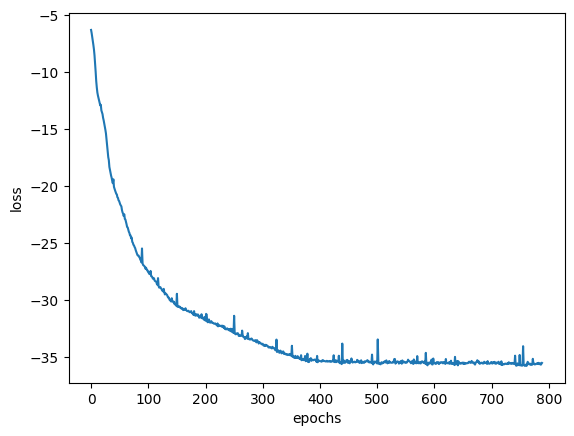

In [16]:
N = D_data.sum()
print(N)

npu,mle = NPU(D_data, H_norm_pT.T, N)

In [17]:
bins = np.asarray(binvals)

In [21]:
# def IBU(ymes,t0,Rin,n):
#     #This is the iterative Bayesian unfolding method.
#     #Rin is a matrix where the first coordinate is the measured value and the second coordinate is the true value.
#     #n is the number of iterations.

#     tn = t0
#     for i in range(n):
#         Rjitni = [np.array(Rin[:][i])*tn[i] for i in range(len(tn))]
#         Pm_given_t = Rjitni / np.matmul(Rin,tn)
#         tn = np.dot(Pm_given_t,ymes)
#         pass
#     return tn

def IBU(data, init, r, det_binwidth=1, mc_binwidth=1, it=10):
    
    # initialize the truth distribution to the prior
    phis = [init]
    
    # iterate the procedure
    for i in range(it):
        
        # update the estimate for the matrix m
        m = r * phis[-1]
        m /= (m.sum(axis=1)[:,np.newaxis] + 10**-50)

        # update the estimate for the truth distribution
        # the factors of binwidth show up here to change probabilities into probability densities
        phis.append(np.dot(m.T, data)*det_binwidth/mc_binwidth)
        
    return phis

In [24]:
T_mc = np.sum(H_pT,axis=1)
D_mc = np.sum(H_pT,axis=0)
IBU(T_mc,D_mc,H_norm_pT.T,5)-T_mc

T_data = np.sum(H_pT_data,axis=1)
D_data = np.sum(H_pT_data,axis=0)

#ibu = (IBU(T_mc, D_data, H_norm_pT.T, 5)-T_data)/T_data
ibu = IBU(D_data, T_mc, H_norm_pT.T, 1, 1, 10)[10]
print(ibu)

[524927.34222708 285432.73750472 112416.64381908  51035.64848934
  24549.39019201   1638.23776776]


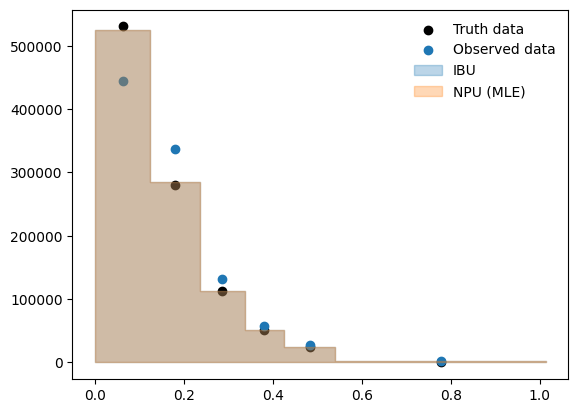

<Figure size 640x480 with 0 Axes>

In [27]:
# plt.scatter(list(0.5*(bins[1:]+bins[:-1]))*1000,npu.reshape(-1), marker='*', label="NPU",s=40)
# train stat = 10000
#plt.errorbar(0.5*(bins[1:]+bins[:-1]), fbu_result_mode, label='FBU mode', xerr=0, yerr=fbu_sigma, marker='o', linestyle='None')
#plt.errorbar(0.5*(bins[1:]+bins[:-1]), fbu_result_mean, label='FBU mean', xerr=0, yerr=fbu_sigma, marker='o', linestyle='None', color='tab:orange')
plt.scatter(0.5*(bins[1:]+bins[:-1]), T_data, color='black', label='Truth data')
plt.scatter(0.5*(bins[1:]+bins[:-1]), D_data, color='tab:blue', label='Observed data')
plt.fill_between(bins, np.insert(ibu, len(ibu), np.array(ibu[-1])), step='post', alpha=0.3, color='tab:blue', label='IBU')
plt.fill_between(bins, np.insert(mle, len(mle), np.array(mle[-1])), step='post', alpha=0.3, color='tab:orange', label='NPU (MLE)')
plt.legend(frameon=False, loc="upper right")
plt.show()
plt.clf()

In [20]:
!python -m pip install corner

Defaulting to user installation because normal site-packages is not writeable


In [21]:
import corner

In [24]:
np.savez_compressed("npu_gaussian_100000.npz", **{"bins": bins, "npu": npu, "mle": mle})

In [26]:
aaa=np.load("npu_gaussian_100000.npz")

In [27]:
list(aaa.keys())

['bins', 'npu', 'mle']

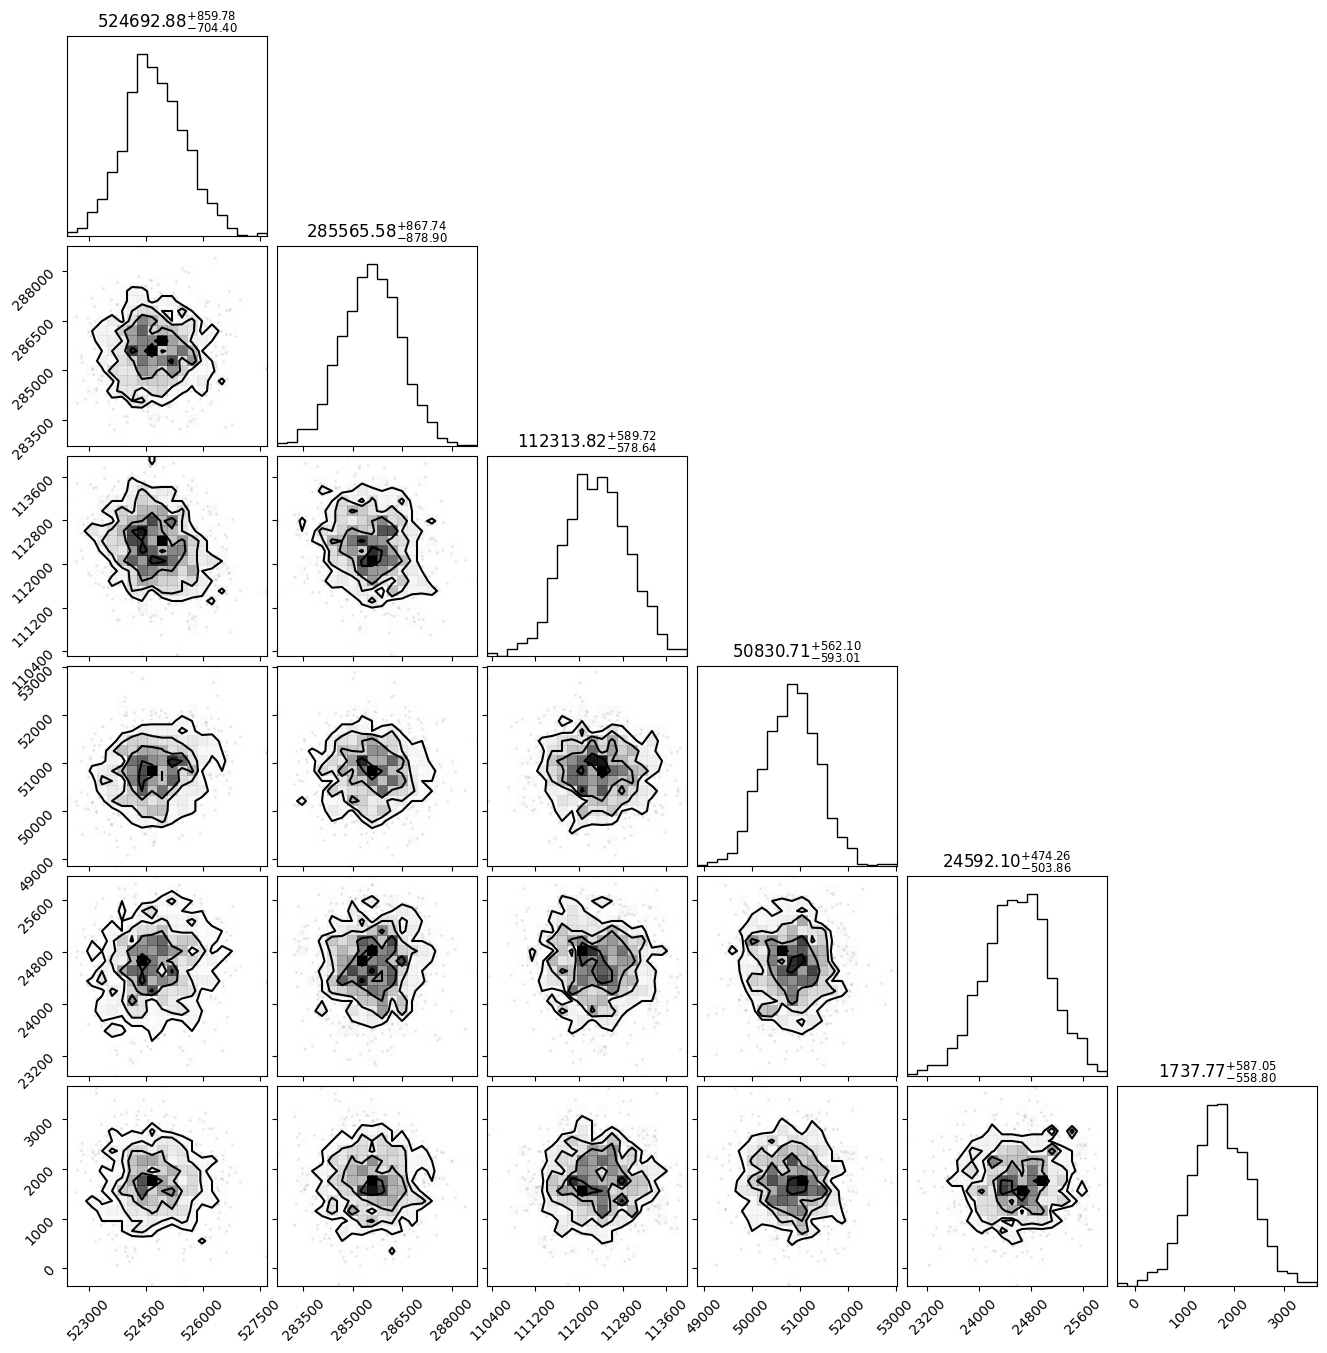

In [28]:
figure = corner.corner(
    npu,
#     labels=[
#         r"Bin Index",
#         r"Bin Index",
#         r"$\log \alpha$",
#         r"$\Gamma \, [\mathrm{parsec}]$",
#     ],
#     quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_kwargs={"fontsize": 12},
)